<a href="https://colab.research.google.com/github/ChamiruGajasinghe/NEXORA_CNN/blob/dumindu-modelB/Dumindu_ModelB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import time
import json
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split          # to split the data
from sklearn.utils.class_weight import compute_class_weight   # to calculate class weights
from sklearn.metrics import (confusion_matrix, classification_report,
                             precision_score, recall_score)   # evaluation tools


seed = 42
random.seed(seed)
np.random.seed(seed)
tf.random.set_seed(seed)

# ---- Basic settings (same as Data_preparation notebook) ----
image_height = 64      # images are resized to 64 x 64
image_width = 64
batch_size = 32        # how many images the model sees at one time
epochs = 30            # assignment says at least 20, so 30 is safe

print("TensorFlow version:", tf.__version__)
print("GPU found:", tf.config.list_physical_devices("GPU"))

TensorFlow version: 2.21.0
GPU found: []


Download the dataset

In [ ]:
# Download the RealWaste dataset from UCI (about 650 MB, takes ~30 seconds)
!wget -q --show-progress https://archive.ics.uci.edu/static/public/908/realwaste.zip -O realwaste.zip

# Unzip it into a folder called realwaste_data
!unzip -oq realwaste.zip -d realwaste_data

# Path where the class folders are
dataset_path = "realwaste_data/realwaste-main/RealWaste"
print(os.listdir(dataset_path))

realwaste.zip           [       <=>          ] 656.65M  30.2MB/s    in 19s     
['Cardboard', 'Paper', 'Miscellaneous Trash', 'Metal', 'Textile Trash', 'Glass', 'Vegetation', 'Plastic', 'Food Organics']


### Class Distribution Analysis
check how many images we have in each class folder and plot their distribution.

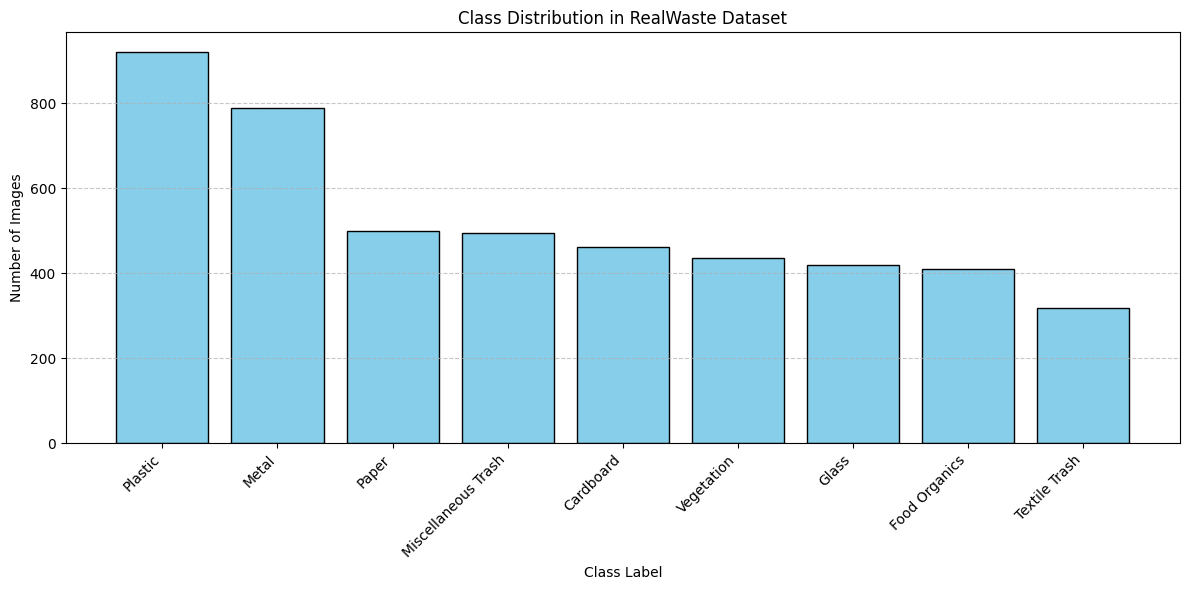

Plastic: 921 images
Metal: 790 images
Paper: 500 images
Miscellaneous Trash: 495 images
Cardboard: 461 images
Vegetation: 436 images
Glass: 420 images
Food Organics: 411 images
Textile Trash: 318 images


In [ ]:
import os
import matplotlib.pyplot as plt

# Count the number of files in each subdirectory of the dataset
class_counts = {}
for class_name in os.listdir(dataset_path):
    class_dir = os.path.join(dataset_path, class_name)
    if os.path.isdir(class_dir):
        # Count only files (images)
        num_images = len([f for f in os.listdir(class_dir) if os.path.isfile(os.path.join(class_dir, f))])
        class_counts[class_name] = num_images

# Sort classes by count for a cleaner visualization
sorted_classes = dict(sorted(class_counts.items(), key=lambda item: item[1], reverse=True))

# Plot the class distribution
plt.figure(figsize=(12, 6))
plt.bar(sorted_classes.keys(), sorted_classes.values(), color='skyblue', edgecolor='black')
plt.title('Class Distribution in RealWaste Dataset')
plt.xlabel('Class Label')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Display the numeric values
for cls, count in sorted_classes.items():
    print(f"{cls}: {count} images")

**Make image paths and labels, then split 70/15/15**

In [ ]:
# Class names = folder names. We sort them so the numbering is always the same
class_names = sorted(os.listdir(dataset_path))
num_classes = len(class_names)
print("Classes:", class_names)

# Make two lists: where each image is, and which class number it belongs to
image_paths = []
labels = []

for class_number, class_name in enumerate(class_names):
    class_path = os.path.join(dataset_path, class_name)
    for image_name in sorted(os.listdir(class_path)):
        image_paths.append(os.path.join(class_path, image_name))
        labels.append(class_number)

# Step 1: take 70% for training, keep 30% aside
# stratify=labels keeps the class proportions the same in every split
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    image_paths, labels, test_size=0.30, random_state=seed, stratify=labels)

# Step 2: divide the 30% equally -> 15% validation + 15% test
val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths, temp_labels, test_size=0.50, random_state=seed, stratify=temp_labels)


print("Train:", len(train_paths), "| Val:", len(val_paths), "| Test:", len(test_paths))

Classes: ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']
Train: 3326 | Val: 713 | Test: 713


**Input pipeline**

In [ ]:

def load_image(image_path, label):
    image = tf.io.read_file(image_path)                       # read the file
    image = tf.image.decode_jpeg(image, channels=3)           # decode to RGB pixels
    image = tf.image.resize(image, [image_height, image_width])  # shrink to 64x64
    image = tf.cast(image, tf.float32) / 255.0                # scale pixels from 0-255 to 0-1
    return image, label
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

AUTOTUNE = tf.data.AUTOTUNE

# Training data: load -> cache in memory -> shuffle -> batch -> augment -> prefetch
train_ds = (tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
            .map(load_image, num_parallel_calls=AUTOTUNE)
            .cache()
            .shuffle(len(train_paths), seed=seed)
            .batch(batch_size)
            .map(lambda x, y: (data_augmentation(x, training=True), y),
                 num_parallel_calls=AUTOTUNE)
            .prefetch(AUTOTUNE))

# Validation data: no shuffle, no augmentation
val_ds = (tf.data.Dataset.from_tensor_slices((val_paths, val_labels))
          .map(load_image, num_parallel_calls=AUTOTUNE)
          .batch(batch_size).cache().prefetch(AUTOTUNE))

# Test data: no shuffle (important! so predictions match the label order later)
test_ds = (tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
           .map(load_image, num_parallel_calls=AUTOTUNE)
           .batch(batch_size).cache().prefetch(AUTOTUNE))

# Quick check of one batch
for images, batch_labels in train_ds.take(1):
    print("Image batch shape:", images.shape)   # expect (32, 64, 64, 3)

Image batch shape: (32, 64, 64, 3)


**Class weights**

In [ ]:
# Some classes have many more images than others (Plastic = 921, Textile = 318).
# Without weights, the model may just favour the big classes.
# "balanced" gives bigger weights to small classes, so their mistakes cost more.
weights = compute_class_weight(class_weight="balanced",
                               classes=np.arange(num_classes),
                               y=np.array(train_labels))

# Keras wants a dictionary like {0: weight, 1: weight, ...}
class_weights = {i: float(w) for i, w in enumerate(weights)}

for i, name in enumerate(class_names):
    print(f"{name:20s} weight = {class_weights[i]:.3f}")

Cardboard            weight = 1.144
Food Organics        weight = 1.283
Glass                weight = 1.257
Metal                weight = 0.668
Miscellaneous Trash  weight = 1.068
Paper                weight = 1.056
Plastic              weight = 0.573
Textile Trash        weight = 1.665
Vegetation           weight = 1.212


**Build Model B**

In [ ]:

def ds_block(x, filters, pool=True):
    x = layers.DepthwiseConv2D((3, 3), padding="same", use_bias=False)(x)  # step 1
    x = layers.BatchNormalization()(x)         # keeps values stable, trains faster
    x = layers.ReLU(max_value=6.0)(x)          # ReLU6 = min(max(0,x), 6), very cheap for hardware

    x = layers.Conv2D(filters, (1, 1), use_bias=False)(x)                  # step 2
    x = layers.BatchNormalization()(x)
    x = layers.ReLU(max_value=6.0)(x)

    if pool:
        x = layers.MaxPooling2D((2, 2))(x)     # halves the image size (e.g. 32x32 -> 16x16)
    return x


def build_model_b():
    inputs = keras.Input(shape=(image_height, image_width, 3))   # 64x64 RGB image

   # Use a normal convolution as the first feature extraction layer
    x = layers.Conv2D(16, (3, 3), padding="same", use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU(max_value=6.0)(x)
    x = layers.MaxPooling2D((2, 2))(x)          # -> 32 x 32 x 16

    # Four depthwise separable blocks, channels grow: 32 -> 64 -> 128 -> 256
    x = ds_block(x, 32,  pool=True)             # -> 16 x 16 x 32
    x = ds_block(x, 64,  pool=True)             # -> 8 x 8 x 64
    x = ds_block(x, 128, pool=True)             # -> 4 x 4 x 128
    x = ds_block(x, 256, pool=False)            # -> 4 x 4 x 256 (no pooling at the end)

    # Global average pooling: each 4x4 map becomes 1 number -> 256 numbers.
    # This avoids a huge Flatten + Dense layer (saves a lot of parameters).
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dropout(0.3)(x)                  # randomly switches off 30% neurons to reduce overfitting
    x = layers.Dense(64)(x)                     # fully connected layer with 64 units
    x = layers.ReLU(max_value=6.0)(x)

    # Output layer: 9 numbers (one per class), softmax makes them add up to 1 (probabilities)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return keras.Model(inputs, outputs, name="model_b_dsconv")


model_b = build_model_b()
model_b.summary()

# Count only trainable parameters (assignment says must be under 100,000)
trainable = int(sum(np.prod(w.shape) for w in model_b.trainable_weights))
print("Trainable parameters:", trainable)

# This line stops the notebook with an error if we ever go over the limit
assert trainable < 100_000, "Model B must be under 100,000 trainable parameters!"
print("Parameter limit OK")

Model: "model_b_dsconv"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 64, 64, 16)     │           432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 64, 64, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_30 (ReLU)                 │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_12             │ (None, 32, 32, 16)     │           144 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_28          │ (None, 32, 32, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_31 (ReLU)                 │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 32, 32, 32)     │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_29          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_32 (ReLU)                 │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_13             │ (None, 16, 16, 32)     │           288 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_30          │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_33 (ReLU)                 │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 16, 16, 64)     │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_31          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_34 (ReLU)                 │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_14             │ (None, 8, 8, 64)       │           576 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_32          │ (None, 8, 8, 64)       │           25

 Total params: 66,089 (258.16 KB)

 Trainable params: 64,617 (252.41 KB)

 Non-trainable params: 1,472 (5.75 KB)

Trainable parameters: 64617
Parameter limit OK


**Manual parameter calculation (for the report)**

In [ ]:
# We calculate the parameters by hand (with formulas) and compare with Keras.
# Same idea  used for Model A.

# Stem: normal 3x3 conv, 3 input channels, 16 filters (no bias) + BatchNorm
# BatchNorm has 2 trainable params per channel (gamma and beta)
stem_conv = 3 * 3 * 3 * 16
stem_bn   = 2 * 16

# One depthwise separable block, going from cin channels to cout channels
def block_params(cin, cout):
    dw    = 3 * 3 * cin      # depthwise 3x3: one 3x3 filter per input channel
    dw_bn = 2 * cin          # BatchNorm after depthwise
    pw    = cin * cout       # pointwise 1x1: cin x cout weights
    pw_bn = 2 * cout         # BatchNorm after pointwise
    return dw + dw_bn + pw + pw_bn

b1 = block_params(16, 32)
b2 = block_params(32, 64)
b3 = block_params(64, 128)
b4 = block_params(128, 256)

dense1 = 256 * 64 + 64                       # Dense(64): weights + biases
out    = 64 * num_classes + num_classes      # Output Dense(9): weights + biases

manual_total = stem_conv + stem_bn + b1 + b2 + b3 + b4 + dense1 + out

print("Stem (conv + BN):", stem_conv + stem_bn)
print("DS Block 1 (16->32):  ", b1)
print("DS Block 2 (32->64):  ", b2)
print("DS Block 3 (64->128): ", b3)
print("DS Block 4 (128->256):", b4)
print("Dense(64):", dense1)
print("Output layer:", out)
print("-----------------------------")
print("Manual trainable total:", manual_total)
print("Keras trainable total :", trainable)   # these two should be exactly equal

Stem (conv + BN): 464
DS Block 1 (16->32):   752
DS Block 2 (32->64):   2528
DS Block 3 (64->128):  9152
DS Block 4 (128->256): 34688
Dense(64): 16448
Output layer: 585
-----------------------------
Manual trainable total: 64617
Keras trainable total : 64617


**Compare MACs with Model A**

In [ ]:
# Model A rebuilt here ONLY to count its MACs (we don't train it in this notebook)
def build_model_a():
    inputs = keras.Input(shape=(image_height, image_width, 3))
    x = layers.Conv2D(16, (3,3), activation="relu", padding="same")(inputs)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Conv2D(32, (3,3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Conv2D(64, (3,3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2,2))(x)
    x = layers.Flatten()(x)
    x = layers.Dense(64, activation="relu")(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)
    return keras.Model(inputs, outputs, name="model_a")

# MAC = multiply-accumulate operations = a measure of computation cost.
# For a conv layer: output_height * output_width * kernel_h * kernel_w * in_channels * out_channels
def count_macs(model):
    total = 0
    for layer in model.layers:
        if isinstance(layer, layers.DepthwiseConv2D):       # depthwise: no "out_channels" multiplication
            kh, kw, cin, _ = layer.kernel.shape
            _, h, w, _ = layer.output.shape
            total += h * w * kh * kw * cin
        elif isinstance(layer, layers.Conv2D):              # normal conv and 1x1 pointwise conv
            kh, kw, cin, cout = layer.kernel.shape
            _, h, w, _ = layer.output.shape
            total += h * w * kh * kw * cin * cout
        elif isinstance(layer, layers.Dense):               # dense: inputs * outputs
            cin, cout = layer.kernel.shape
            total += cin * cout
    return total

model_a_ref = build_model_a()
macs_a = count_macs(model_a_ref)
macs_b = count_macs(model_b)

print(f"Model A: {model_a_ref.count_params():,} params | {macs_a/1e6:.2f} M MACs")
print(f"Model B: {model_b.count_params():,} params | {macs_b/1e6:.2f} M MACs")
print(f"MAC reduction (A / B): {macs_a/macs_b:.2f}x")

Model A: 286,377 params | 11.47 M MACs
Model B: 66,089 params | 4.16 M MACs
MAC reduction (A / B): 2.76x


**Compile and train**

In [ ]:
# Set total epochs to 30
epochs = 30

# Small helper that records how long each epoch takes (needed for the comparison table)
class EpochTimer(keras.callbacks.Callback):
    def on_train_begin(self, logs=None):
        self.times = []
    def on_epoch_begin(self, epoch, logs=None):
        self.t0 = time.time()
    def on_epoch_end(self, epoch, logs=None):
        self.times.append(time.time() - self.t0)

# Compile = tell the model HOW to learn
model_b.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),   # Adam with lr 0.001
    loss="sparse_categorical_crossentropy",                # labels are integers 0-8
    metrics=["accuracy"],
)

timer = EpochTimer()

callbacks = [
    timer,
    # Save the model only when validation accuracy improves
    keras.callbacks.ModelCheckpoint("model_b_best.keras", monitor="val_accuracy",
                                    save_best_only=True, verbose=1),
    # Reduce learning rate if validation loss plateaus for 4 epochs
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                      patience=4, min_lr=1e-5, verbose=1),
]

# Train the model for 30 epochs using class weights
history = model_b.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,                # Trains for exactly 30 epochs
    class_weight=class_weights,
    callbacks=callbacks,
)

print(f"Average training time per epoch: {np.mean(timer.times):.2f} seconds")

Epoch 1/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.2379 - loss: 1.9995
Epoch 1: val_accuracy improved from None to 0.08836, saving model to model_b_best.keras

Epoch 1: finished saving model to model_b_best.keras
104/104 ━━━━━━━━━━━━━━━━━━━━ 29s 217ms/step - accuracy: 0.3214 - loss: 1.7988 - val_accuracy: 0.0884 - val_loss: 2.2172 - learning_rate: 0.0010
Epoch 2/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - accuracy: 0.4601 - loss: 1.4568
Epoch 2: val_accuracy improved from 0.08836 to 0.19355, saving model to model_b_best.keras

Epoch 2: finished saving model to model_b_best.keras
104/104 ━━━━━━━━━━━━━━━━━━━━ 41s 222ms/step - accuracy: 0.4633 - loss: 1.4342 - val_accuracy: 0.1935 - val_loss: 2.3035 - learning_rate: 0.0010
Epoch 3/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.4953 - loss: 1.2764
Epoch 3: val_accuracy did not improve from 0.19355
104/104 ━━━━━━━━━━━━━━━━━━━━ 21s 198ms/step - accuracy: 0.5075 - loss: 1.2801 - val_accuracy: 0.1332 - val_los

**Loss and accuracy curves**

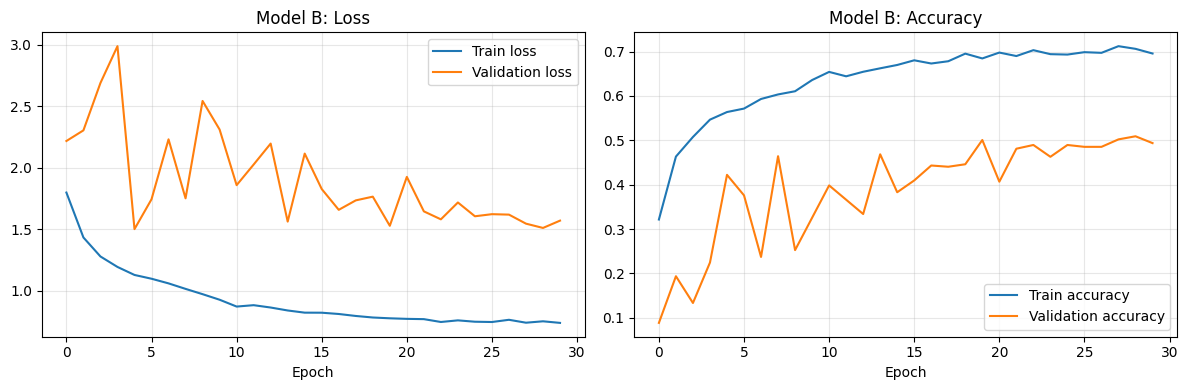

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

# Left graph: loss (should go down)
ax[0].plot(history.history["loss"], label="Train loss")
ax[0].plot(history.history["val_loss"], label="Validation loss")
ax[0].set_title("Model B: Loss")
ax[0].set_xlabel("Epoch")
ax[0].legend()
ax[0].grid(alpha=0.3)

# Right graph: accuracy (should go up)
ax[1].plot(history.history["accuracy"], label="Train accuracy")
ax[1].plot(history.history["val_accuracy"], label="Validation accuracy")
ax[1].set_title("Model B: Accuracy")
ax[1].set_xlabel("Epoch")
ax[1].legend()
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("model_b_curves.png", dpi=150)   # saved image for the report
plt.show()

**Test evaluation, confusion matrix, precision and recall**

Test loss: 1.4690 | Test accuracy: 0.5203

Classification report:

                     precision    recall  f1-score   support

          Cardboard     0.4656    0.8841    0.6100        69
      Food Organics     0.5957    0.4516    0.5138        62
              Glass     0.7500    0.5238    0.6168        63
              Metal     0.6867    0.4831    0.5672       118
Miscellaneous Trash     0.3857    0.3600    0.3724        75
              Paper     0.3537    0.6933    0.4685        75
            Plastic     0.6761    0.3478    0.4593       138
      Textile Trash     0.4074    0.2292    0.2933        48
         Vegetation     0.5806    0.8308    0.6835        65

           accuracy                         0.5203       713
          macro avg     0.5446    0.5337    0.5094       713
       weighted avg     0.5658    0.5203    0.5115       713

Macro precision: 0.5446 | Macro recall: 0.5337


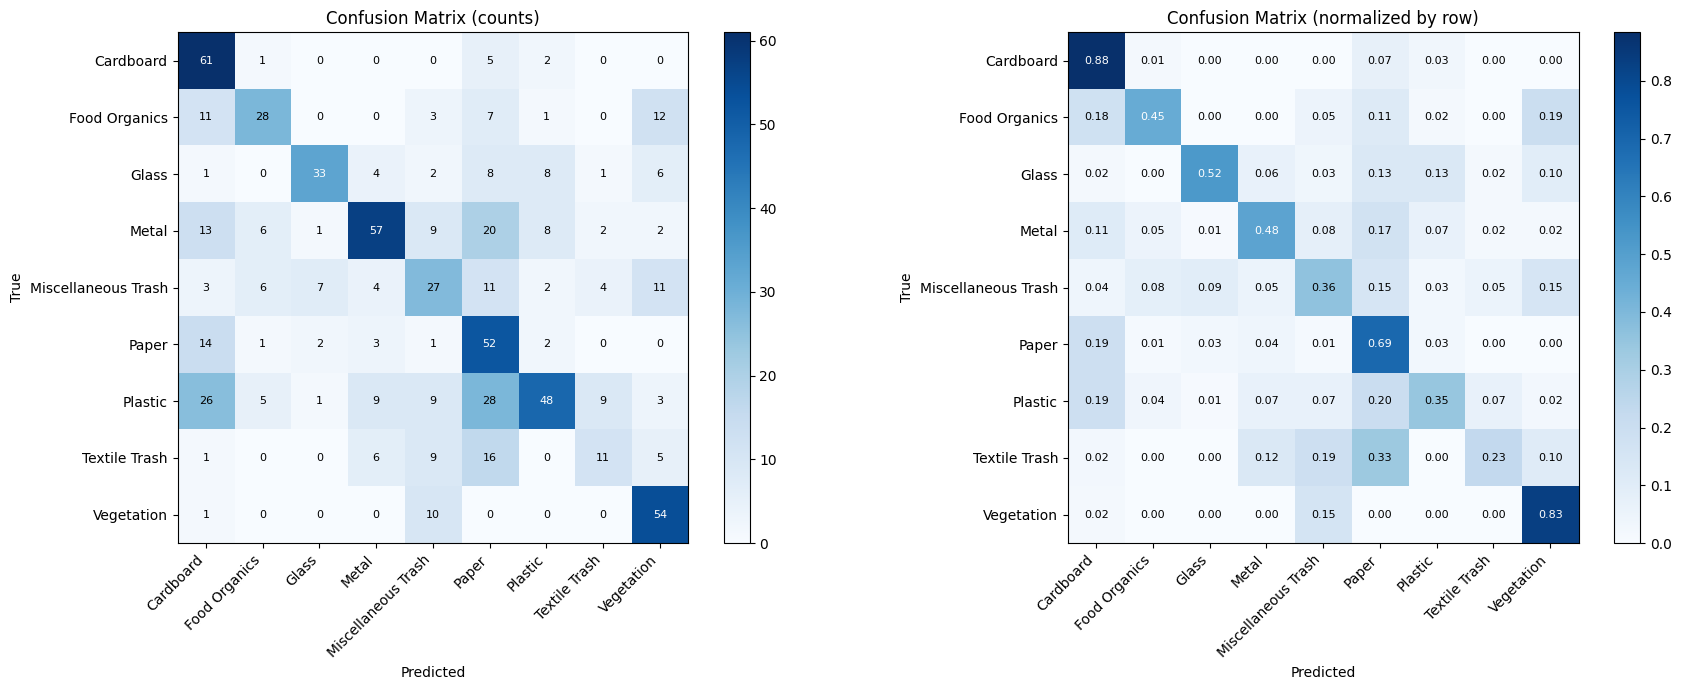

In [ ]:
# Load the best saved model (the epoch with highest validation accuracy)
best_model = keras.models.load_model("model_b_best.keras")

# Final score on the test set (images the model has never seen)
test_loss, test_acc = best_model.evaluate(test_ds, verbose=0)
print(f"Test loss: {test_loss:.4f} | Test accuracy: {test_acc:.4f}")

# Get predictions. Model gives 9 probabilities per image; argmax picks the biggest one
y_prob = best_model.predict(test_ds, verbose=0)
y_pred = np.argmax(y_prob, axis=1)
y_true = np.array(test_labels)    # real labels (same order because test_ds is not shuffled)

# Precision / recall / f1 for each class
print("\nClassification report:\n")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

# Overall (macro) precision and recall = simple average over the 9 classes
macro_p = precision_score(y_true, y_pred, average="macro")
macro_r = recall_score(y_true, y_pred, average="macro")
print(f"Macro precision: {macro_p:.4f} | Macro recall: {macro_r:.4f}")

# ---- Confusion matrix ----
# Rows = true class, columns = predicted class. Diagonal = correct predictions.
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)   # each row as a percentage

fig, ax = plt.subplots(1, 2, figsize=(18, 7))
for a, data, title, fmt in [(ax[0], cm, "Confusion Matrix (counts)", "d"),
                            (ax[1], cm_norm, "Confusion Matrix (normalized by row)", ".2f")]:
    im = a.imshow(data, cmap="Blues")
    a.set_title(title)
    a.set_xticks(range(num_classes))
    a.set_yticks(range(num_classes))
    a.set_xticklabels(class_names, rotation=45, ha="right")
    a.set_yticklabels(class_names)
    a.set_xlabel("Predicted")
    a.set_ylabel("True")

    # write the number inside each box (white text on dark boxes so it's readable)
    thresh = data.max() / 2
    for i in range(num_classes):
        for j in range(num_classes):
            a.text(j, i, format(data[i, j], fmt), ha="center", va="center",
                   color="white" if data[i, j] > thresh else "black", fontsize=8)
    plt.colorbar(im, ax=a, fraction=0.046)

plt.tight_layout()
plt.savefig("model_b_confusion_matrix.png", dpi=150)
plt.show()

**Model size and TFLite**

In [ ]:
# Size of the saved model file on disk
size_keras_kb = os.path.getsize("model_b_best.keras") / 1024

# Theoretical size: each parameter is a 32-bit float = 4 bytes
size_fp32_kb_est = best_model.count_params() * 4 / 1024

print(f"Keras file size       : {size_keras_kb:.1f} KB")
print(f"Estimated float32 size: {size_fp32_kb_est:.1f} KB")

# Convert to TFLite = the format used on Raspberry Pi / microcontrollers.
# Wrapped in try/except so the notebook doesn't crash if conversion has a problem.
try:
    # normal float32 version
    conv = tf.lite.TFLiteConverter.from_keras_model(best_model)
    tflite_fp32 = conv.convert()
    open("model_b_fp32.tflite", "wb").write(tflite_fp32)

    # quantized version (weights stored as 8-bit -> about 4x smaller)
    conv = tf.lite.TFLiteConverter.from_keras_model(best_model)
    conv.optimizations = [tf.lite.Optimize.DEFAULT]
    tflite_q = conv.convert()
    open("model_b_int8.tflite", "wb").write(tflite_q)

    print(f"TFLite float32  : {len(tflite_fp32)/1024:.1f} KB")
    print(f"TFLite quantized: {len(tflite_q)/1024:.1f} KB")
except Exception as e:
    print("TFLite conversion skipped:", e)

Keras file size       : 915.0 KB
Estimated float32 size: 258.2 KB
Saved artifact at '/tmp/tmpiujcbwjq'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name='input_layer_6')
Output Type:
  TensorSpec(shape=(None, 9), dtype=tf.float32, name=None)
Captures:
  138280324127568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138280324131792: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138280324131600: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138280324131984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138280324127376: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138280324132176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138280324136400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138280324136208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138280350992528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138280324127760: Te